In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import shapfrom sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# using suppress warnings for clean output
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [ ]:
df = pd.read_csv('/content/Credit_Card.csv', sep=';', on_bad_lines='warn', low_memory=False)

# showing the first 5 rows to understand the structure
print("First 5 rows : ")
print(df.head())

print("Data types and non-null counts")
print(df.info())

print("Descriptive statistics")
print(df.describe(include='all').T)

First 5 rows : 
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE   AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0  2.0        2.0       NaN  24.0      2      2     -1     -1   
1   2   120000.0  2.0        2.0       2.0  26.0     -1      2      0      0   
2   3    90000.0  2.0        2.0       2.0  34.0      0      0      0      0   
3   4    50000.0  2.0        2.0       1.0  37.0      0      0      0      0   
4   5    50000.0  1.0        2.0       1.0  57.0     -1      0     -1      0   

   ...  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  \
0  ...       0.0       0.0       0.0       0.0                           1   
1  ...    1000.0    1000.0       0.0    2000.0                           1   
2  ...    1000.0    1000.0    1000.0    5000.0                           0   
3  ...    1200.0    1100.0    1069.0    1000.0                           0   
4  ...   10000.0    9000.0     689.0     679.0                           0   

                risk_leak  BILL_AM

TARGET VARIABLE DISTRIBUTION

Class 0 (No Default): 28,132 (80.9%)
Class 1 (Default):    6,656 (19.1%)

IMBALANCE RATIO: 4.2:1 (No Default : Default)
INSIGHT: The dataset is heavily imbalanced (~80%/~20%).
Standard Accuracy is misleading , use Recall, F1, AUC-ROC.


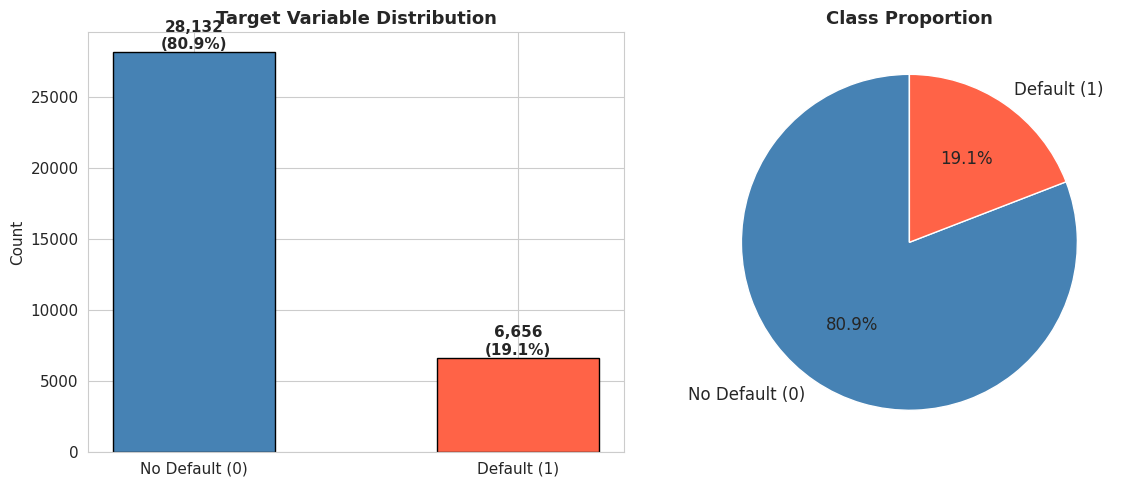

In [ ]:
# Task 1: Investigate the distribution of the target variable
# and discuss the class imbalance observed.
print("TARGET VARIABLE DISTRIBUTION")

# Count and percentage of each classes
target_counts = df['default.payment.next.month'].value_counts()
target_pct    = df['default.payment.next.month'].value_counts(normalize=True) * 100

print(f"Class 0 (No Default): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"Class 1 (Default):    {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"IMBALANCE RATIO: {target_counts[0]/target_counts[1]:.1f}:1 (No Default : Default)")
print("INSIGHT: The dataset is heavily imbalanced (~80%/~20%).")
print("Standard Accuracy is misleading , use Recall, F1, AUC-ROC.")

# Visualise target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['No Default (0)', 'Default (1)'],
            [target_counts[0], target_counts[1]],
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 200, f'{v:,}\n({[target_pct[0], target_pct[1]][i]:.1f}%)',
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[0], target_counts[1]],
            labels=['No Default (0)', 'Default (1)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', bbox_inches='tight')
plt.show()




In [ ]:
# Mean, Median, Std for LIMIT_BAL, AGE, BILL_AMT_SUM,
# LIMIT_BAL_LOG, and risk_leak

# LIMIT_BAL_LOG is stored in European locale
# format (dots as thousand separators, e.g. '11.695.255...')
# it must be fixed BEFORE computing statistics.

# risk_leak contains the same dot-separator
# issue AND some values in scientific notation with commas
# (e.g. '-9,27E+10'). Both must be fixed first.

def fix_european_number(raw):

    s = str(raw).strip()
    if pd.isna(raw) or s == 'nan':
        return np.nan
    s = s.replace(',', '.')
    dot_count = s.count('.')
    if dot_count == 0:
        try:
            return float(s)
        except:
            return np.nan
    if dot_count == 1:
        try:
            return float(s)
        except:
            return np.nan

    digits_only = s.replace('.', '')
    sign = ''
    if digits_only.startswith('-'):
        sign = '-'
        digits_only = digits_only[1:]
    for decimal_pos in [1, 2]:
        try:
            candidate = float(sign + digits_only[:decimal_pos] + '.' + digits_only[decimal_pos:])
            if 8.0 < abs(candidate) < 16.0:
                return candidate
        except:
            pass
    try:
        return float(sign + digits_only)
    except:
        return np.nan

# we first fix on a copy to inspect right before modify df
df['LIMIT_BAL_LOG'] = df['LIMIT_BAL_LOG'].apply(fix_european_number)

# risk_leak is named 'risk_LEAK' intentionally , it is a DATA LEAKAGE feature. We fix and show the stats here but DROP it before training.
df['risk_leak_fixed'] = df['risk_leak'].apply(fix_european_number)

print("DESCRIPTIVE STATISTICS FOR KEY NUMERICAL FEATURES")
print("---------------------------------------")

# Compute statistics for required features
key_features = {
    'LIMIT_BAL'    : df['LIMIT_BAL'],
    'AGE'          : df['AGE'],
    'BILL_AMT_SUM' : df['BILL_AMT_SUM'],
    'LIMIT_BAL_LOG': df['LIMIT_BAL_LOG'],
    'risk_leak'    : df['risk_leak_fixed'],
}

stats_df = pd.DataFrame({
    feat: {
        'Count'  : series.count(),
        'Mean'   : series.mean(),
        'Median' : series.median(),
        'Std Dev': series.std(),
        'Min'    : series.min(),
        'Max'    : series.max(),
        'Missing': series.isna().sum()
    }
    for feat, series in key_features.items()
}).T.round(4)

print(stats_df.to_string())
print("NOTE: risk_leak has extreme range (billions) , strong indicator of a leaky/corrupted feature. Will be DROPPED before training.")
print("NOTE: LIMIT_BAL_LOG = log(LIMIT_BAL) , reconstructed from European locale format. Values ~9 to ~15.5 are correct.")

DESCRIPTIVE STATISTICS FOR KEY NUMERICAL FEATURES
---------------------------------------
                 Count          Mean       Median       Std Dev           Min           Max  Missing
LIMIT_BAL      33079.0  1.846690e+05  140000.0000  2.359319e+05  1.000000e+04  5.600000e+06   1709.0
AGE            33033.0  3.551830e+01      34.0000  9.236800e+00  2.100000e+01  7.900000e+01   1755.0
BILL_AMT_SUM   34788.0  2.948152e+05  129037.0000  5.718073e+05 -3.362590e+05  2.129266e+07      0.0
LIMIT_BAL_LOG  33079.0  1.167520e+01      11.8494  9.372000e-01  9.210400e+00  1.381550e+01   1709.0
risk_leak      34788.0 -5.694061e+07       0.0307  5.113956e+09 -5.350000e+11  4.120000e+11      0.0

NOTE: risk_leak has extreme range (billions) , strong indicator of a leaky/corrupted feature. Will be DROPPED before training.
NOTE: LIMIT_BAL_LOG = log(LIMIT_BAL) , reconstructed from European locale format. Values ~9 to ~15.5 are correct.


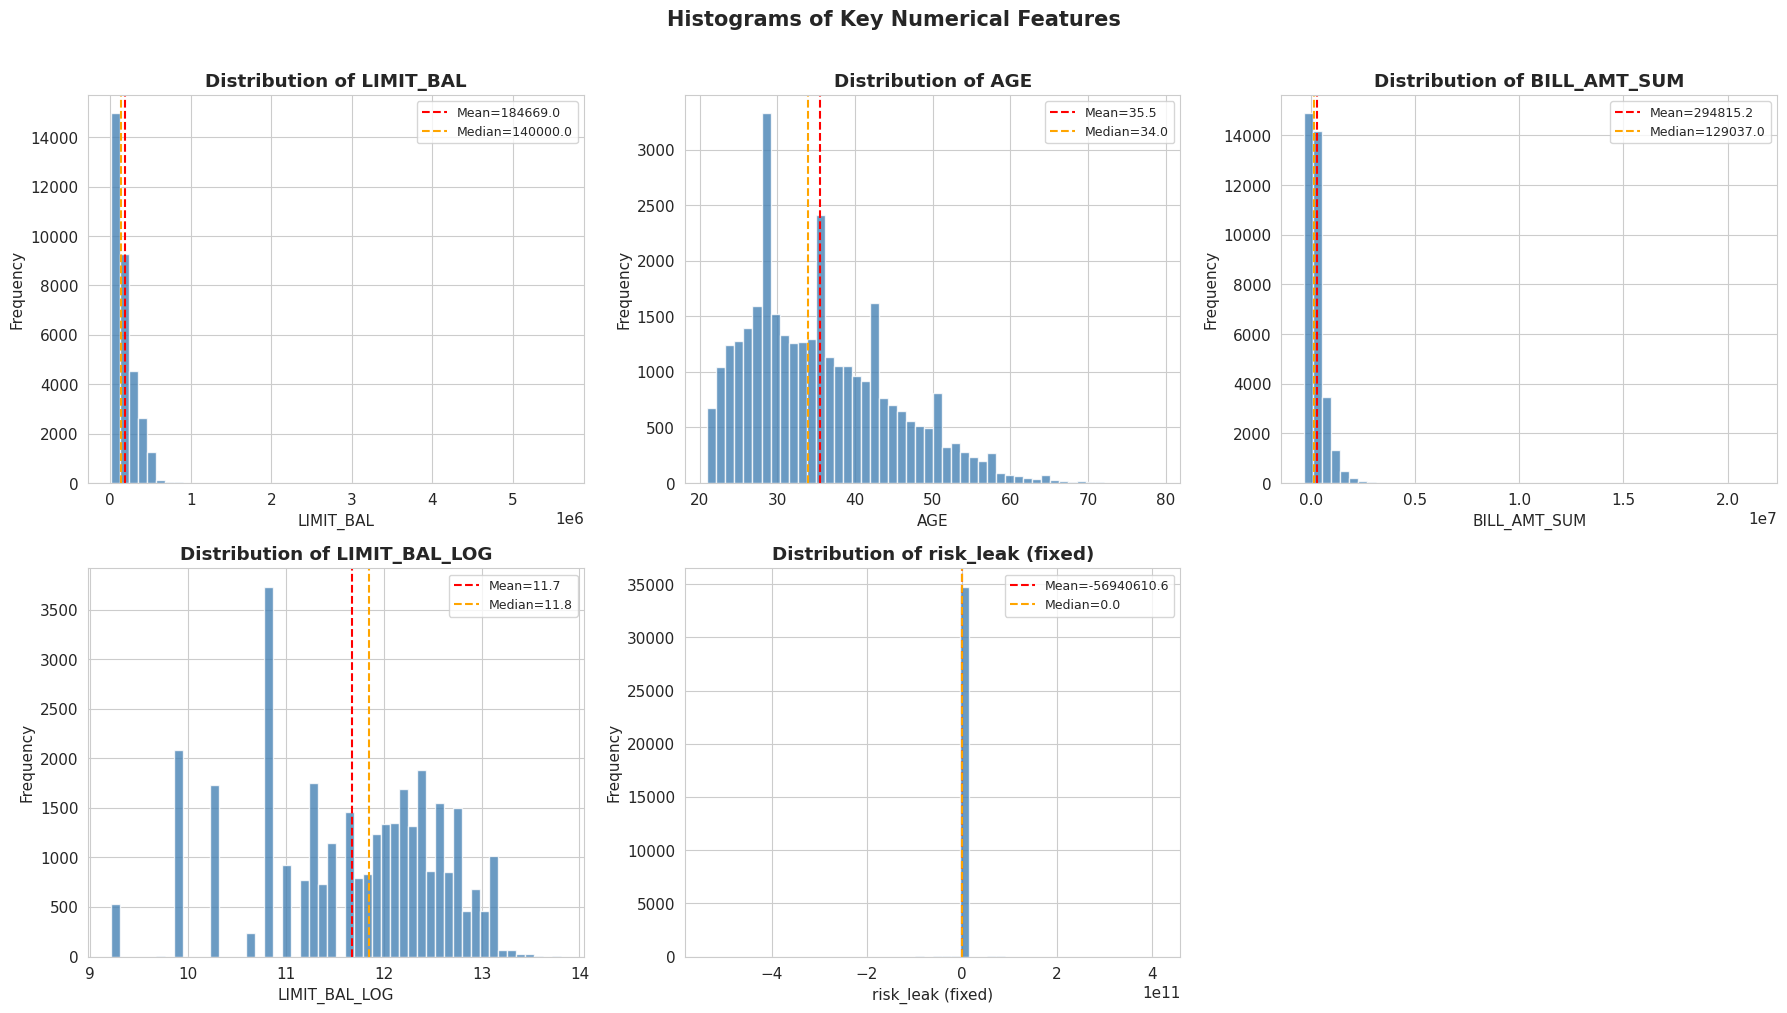

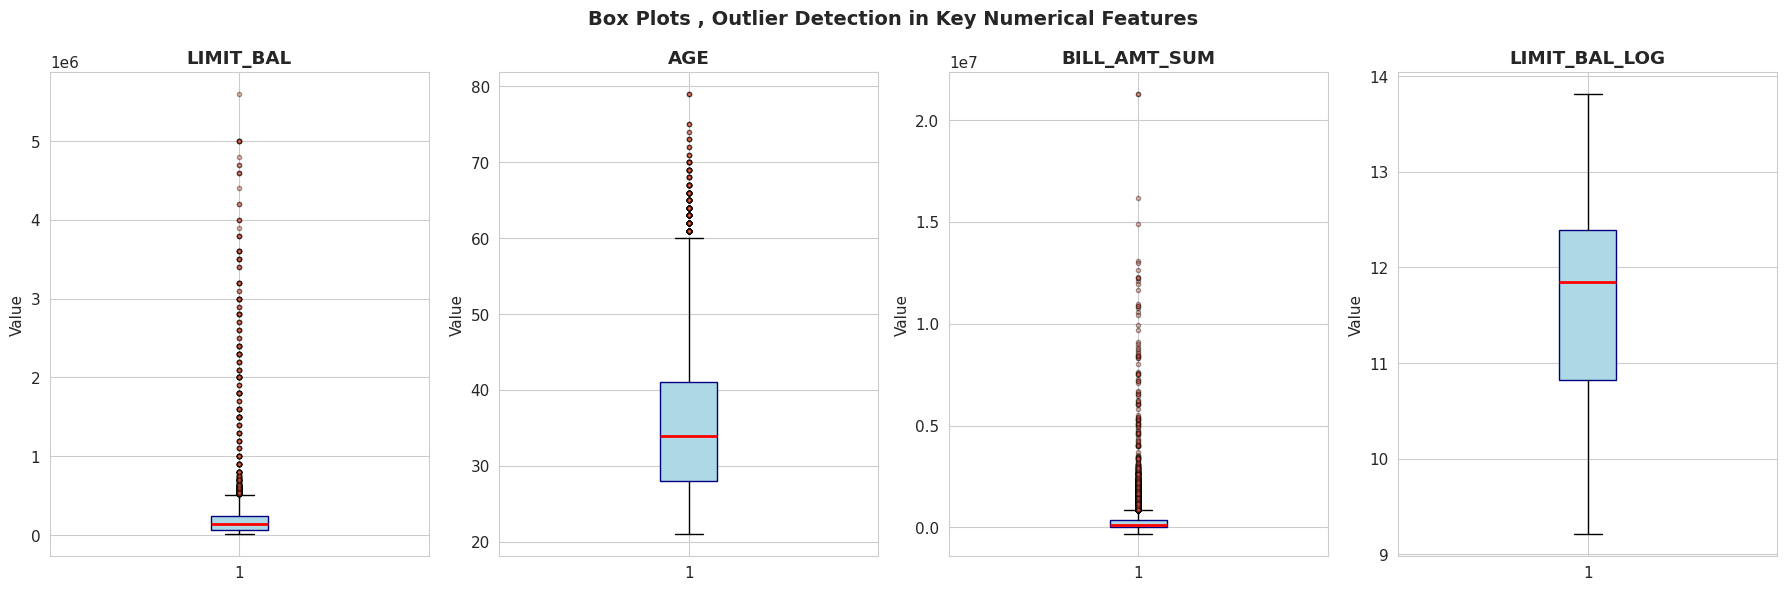

In [ ]:
# Task 1: Identify trends, outliers, and skewness

numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak_fixed']
num_labels         = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak (fixed)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(numerical_features, num_labels)):
    data = df[feat].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median={data.median():.1f}')
    axes[i].set_title(f'Distribution of {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

# hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Histograms of Key Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_numerical_histograms.png', bbox_inches='tight')
plt.show()

# box Plots for outlier detection
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
box_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG']

for i, feat in enumerate(box_features):
    axes[i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='tomato',
                                    markersize=3, alpha=0.4))
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots , Outlier Detection in Key Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_boxplots_outliers.png', bbox_inches='tight')
plt.show()

CATEGORICAL FEATURE DISTRIBUTIONS
---------------------------------------


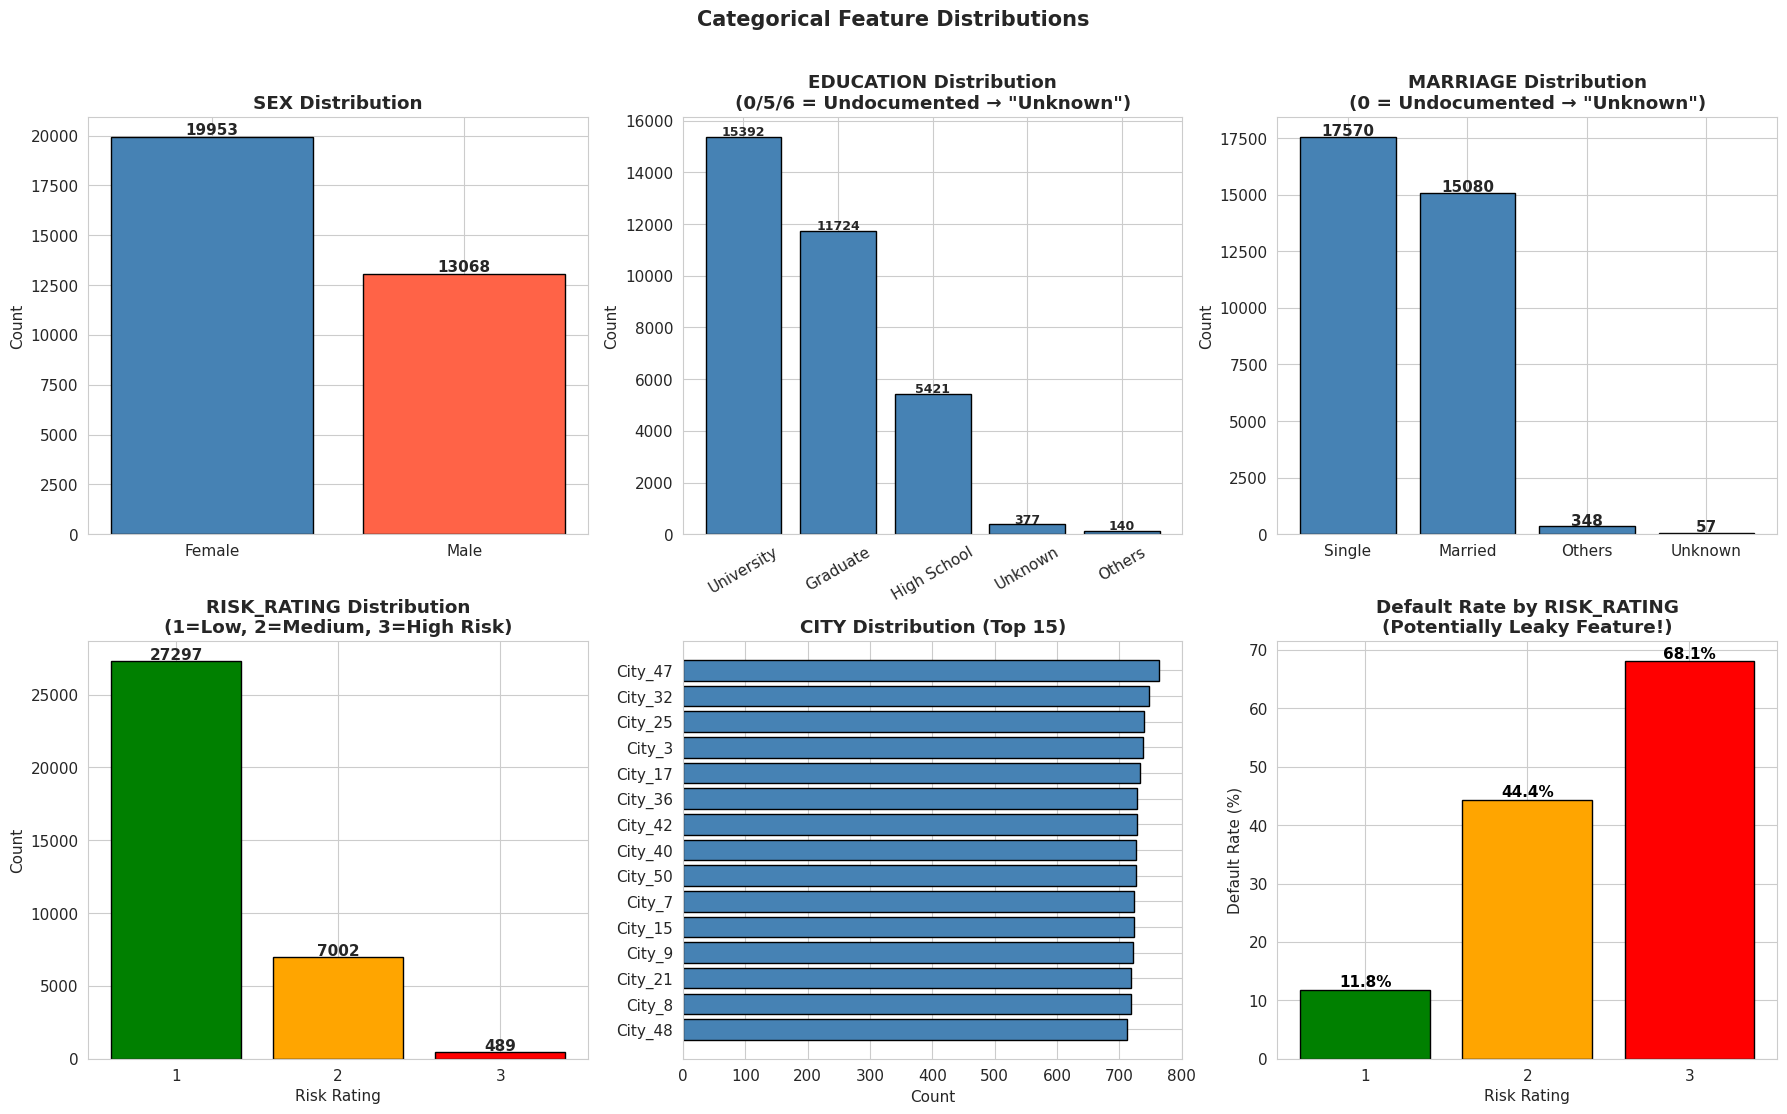


NOTE: RISK_RATING=3 has high default rate , may be semi-leaky.
NOTE: CITY has 50 unique values , high cardinality.


In [ ]:
# task 1: SEX, EDUCATION, MARRIAGE, CITY, RISK_RATING
# EDUCATION has undocumented values 0, 5, 6
#  MARRIAGE has undocumented value 0

print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("---------------------------------------")

# SEX mapping
sex_map  = {1.0: 'Male', 2.0: 'Female'}
edu_map  = {1.0: 'Graduate', 2.0: 'University', 3.0: 'High School',
            4.0: 'Others', 0.0: 'Unknown', 5.0: 'Unknown', 6.0: 'Unknown'}
mar_map  = {1.0: 'Married', 2.0: 'Single', 3.0: 'Others', 0.0: 'Unknown'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# SEX
sex_counts = df['SEX'].map(sex_map).value_counts()
axes[0,0].bar(sex_counts.index, sex_counts.values, color=['steelblue','tomato'],
              edgecolor='black')
axes[0,0].set_title('SEX Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for j, v in enumerate(sex_counts.values):
    axes[0,0].text(j, v + 100, str(v), ha='center', fontweight='bold')

# EDUCATION (showing undocumented values 0, 5, 6)
edu_counts = df['EDUCATION'].map(edu_map).value_counts()
axes[0,1].bar(edu_counts.index, edu_counts.values, color='steelblue', edgecolor='black')
axes[0,1].set_title('EDUCATION Distribution(0/5/6 = Undocumented → "Unknown")',
                     fontweight='bold')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=30)
for j, v in enumerate(edu_counts.values):
    axes[0,1].text(j, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)

# MARRIAGE (showing undocumented value 0)
mar_counts = df['MARRIAGE'].map(mar_map).value_counts()
axes[0,2].bar(mar_counts.index, mar_counts.values, color='steelblue', edgecolor='black')
axes[0,2].set_title('MARRIAGE Distribution(0 = Undocumented → "Unknown")',
                     fontweight='bold')
axes[0,2].set_ylabel('Count')
for j, v in enumerate(mar_counts.values):
    axes[0,2].text(j, v + 50, str(v), ha='center', fontweight='bold')

# RISK_RATING
rr_counts = df['RISK_RATING'].value_counts().sort_index()
colors_rr = ['green', 'orange', 'red']
axes[1,0].bar([str(x) for x in rr_counts.index], rr_counts.values,
              color=colors_rr, edgecolor='black')
axes[1,0].set_title('RISK_RATING Distribution\n(1=Low, 2=Medium, 3=High Risk)',
                     fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xlabel('Risk Rating')
for j, v in enumerate(rr_counts.values):
    axes[1,0].text(j, v + 100, str(v), ha='center', fontweight='bold')

# CITY (top 15 cities only for readability)
city_counts = df['CITY'].value_counts().head(15)
axes[1,1].barh(city_counts.index[::-1], city_counts.values[::-1], color='steelblue',
               edgecolor='black')
axes[1,1].set_title('CITY Distribution (Top 15)', fontweight='bold')
axes[1,1].set_xlabel('Count')

# RISK_RATING vs Default Rate
rr_default = df.groupby('RISK_RATING')['default.payment.next.month'].mean() * 100
axes[1,2].bar([str(x) for x in rr_default.index], rr_default.values,
              color=['green','orange','red'], edgecolor='black')
axes[1,2].set_title('Default Rate by RISK_RATING\n(Potentially Leaky Feature!)',
                     fontweight='bold')
axes[1,2].set_ylabel('Default Rate (%)')
axes[1,2].set_xlabel('Risk Rating')
for j, v in enumerate(rr_default.values):
    axes[1,2].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', color='black')

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_categorical_distributions.png', bbox_inches='tight')
plt.show()
print("\nNOTE: RISK_RATING=3 has high default rate , may be semi-leaky.")
print("NOTE: CITY has 50 unique values , high cardinality.")


CORRELATION ANALYSIS WITH TARGET
-----------------------------------------


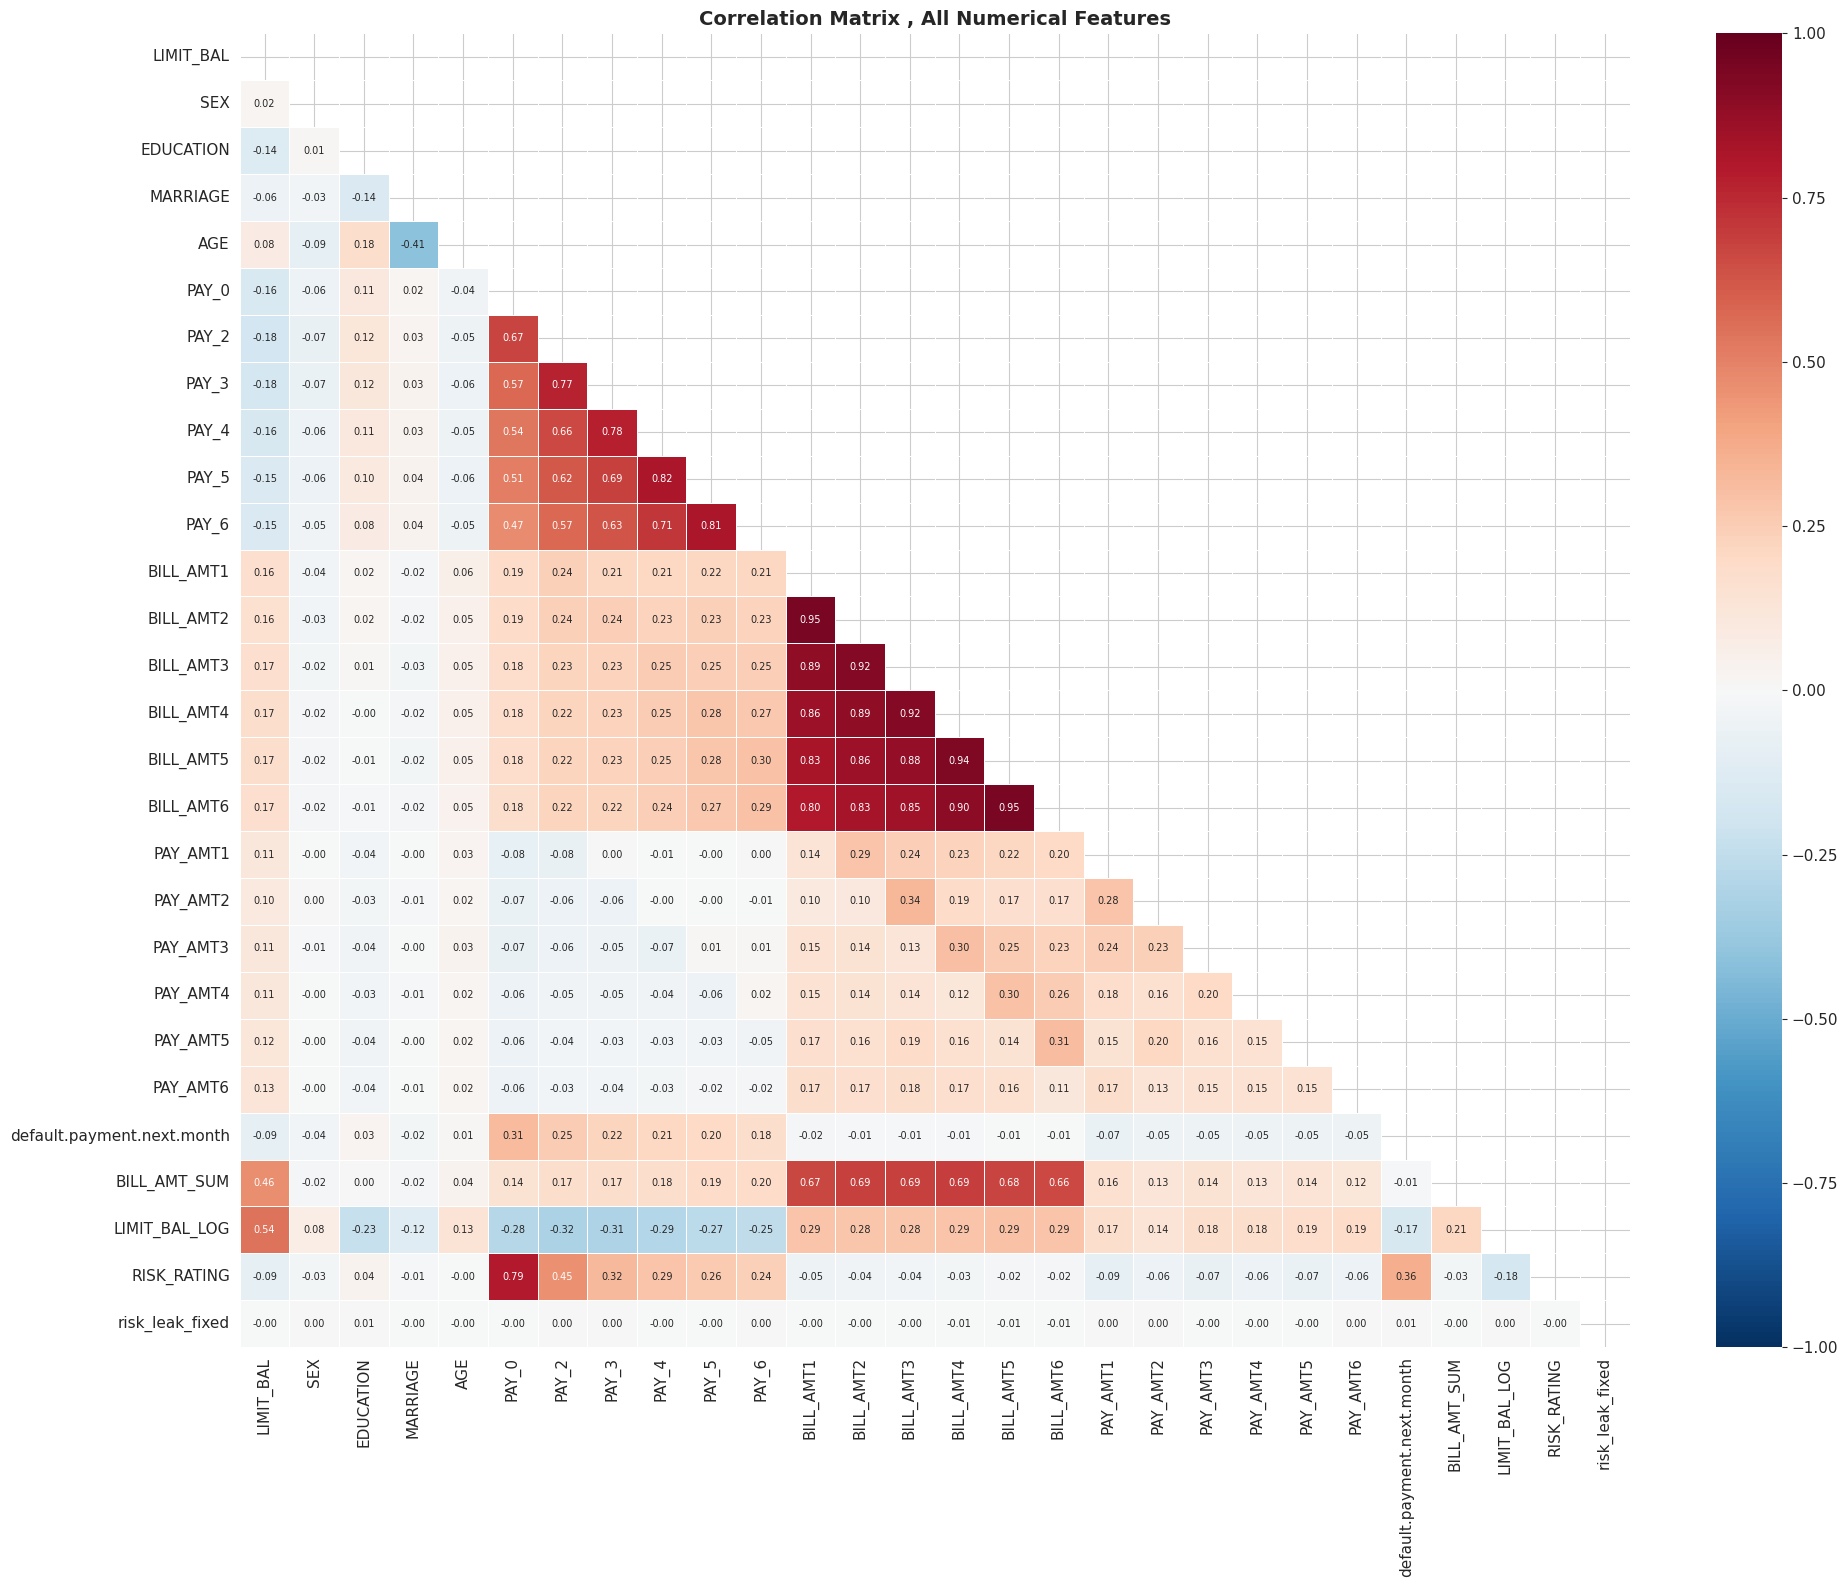

In [ ]:
# task 1: Correlations between numerical features and target and identify features most strongly linked to default risk

print("CORRELATION ANALYSIS WITH TARGET")
print("-----------------------------------------")

# compute correlation of all numerical features with target only include numeric columns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID and the unfixed risk_leak (keep risk_leak_fixed)
numeric_cols = [c for c in numeric_cols if c not in ['ID', 'risk_leak']]

# Correlation heatmap (full)
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 7})
plt.title('Correlation Matrix , All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# target correlation bar chart
target_corr = df[numeric_cols].corr()['default.payment.next.month'].drop(
    'default.payment.next.month').sort_values(key=abs, ascending=False)



Feature correlations with target (absolute, descending):
RISK_RATING        0.362487
PAY_0              0.314230
PAY_2              0.253757
PAY_3              0.224862
PAY_4              0.207571
PAY_5              0.196277
PAY_6              0.179303
LIMIT_BAL_LOG     -0.165921
LIMIT_BAL         -0.089601
PAY_AMT1          -0.069158
PAY_AMT3          -0.053304
PAY_AMT4          -0.052782
PAY_AMT5          -0.052321
PAY_AMT2          -0.051469
PAY_AMT6          -0.049474
SEX               -0.036020
EDUCATION          0.028543
MARRIAGE          -0.024416
BILL_AMT1         -0.018940
BILL_AMT2         -0.014030
BILL_AMT3         -0.013771
AGE                0.011700
BILL_AMT_SUM      -0.010079
BILL_AMT4         -0.009931
BILL_AMT5         -0.007094
BILL_AMT6         -0.005909
risk_leak_fixed    0.005416


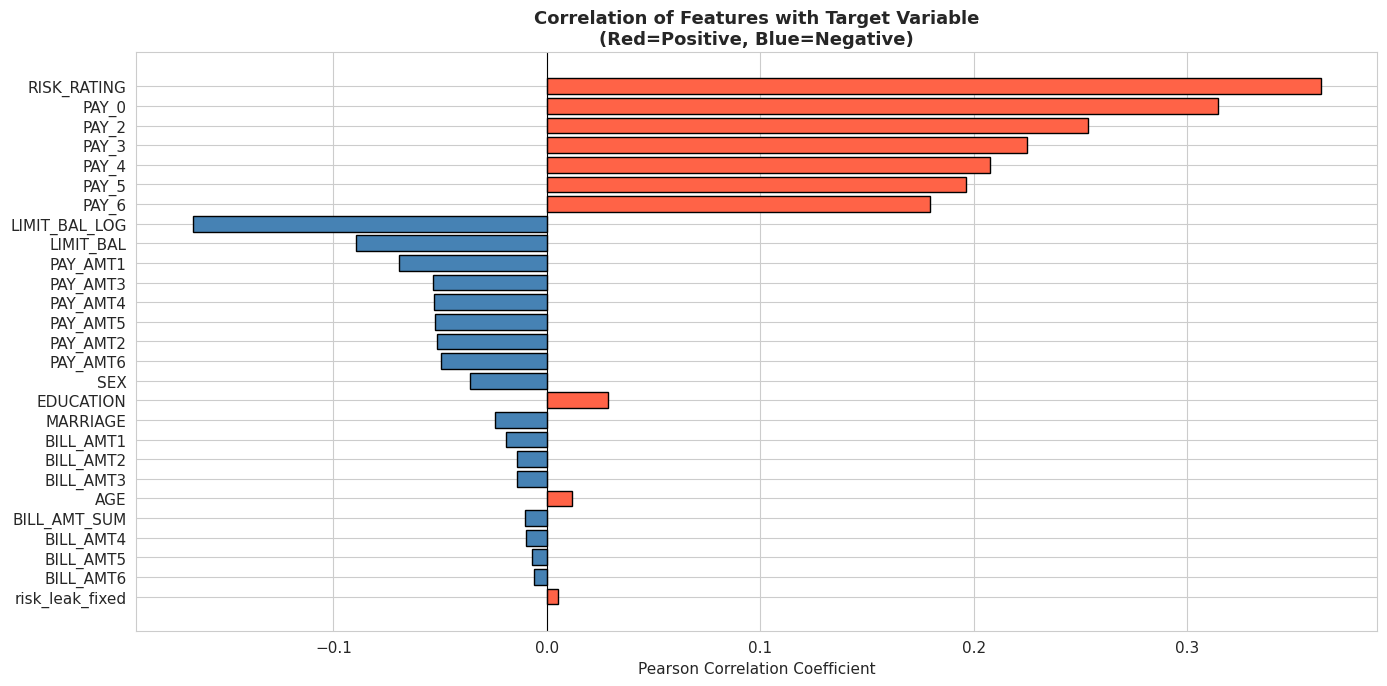


KEY INSIGHTS:
- PAY_0 to PAY_6: payment status columns are strongest predictors.
- RISK_RATING : High correlation , potentially leaky .
- risk_leak_fixed : Extreme range suggests data leakage , will be droppeed.
- LIMIT_BAL : Negative correlation, higher limit , means: lower default risk.
- BILL_AMT_SUM : weak positive correlation with default.


In [ ]:
print("Feature correlations with target (absolute, descending):")
print(target_corr.to_string())

plt.figure(figsize=(14, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr.values]
plt.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1],
         edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Features with Target Variable\n(Red=Positive, Blue=Negative)',
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('06_target_correlation.png', bbox_inches='tight')
plt.show()

print("KEY INSIGHTS:")
print("- PAY_0 to PAY_6: payment status columns are strongest predictors.")
print("- RISK_RATING : High correlation , potentially leaky .")
print("- risk_leak_fixed : Extreme range suggests data leakage , will be droppeed.")
print("- LIMIT_BAL : Negative correlation, higher limit , means: lower default risk.")
print("- BILL_AMT_SUM : weak positive correlation with default.")

In [47]:
# task 2: data preparation
print("TASK 2: DATA PREPARATION")
print("------------------------------------------------")

# identify all missing values, describe and justify the chosen handling method for each of them
print("Missing Values Summary (Before) ")
missing_before = df.isnull().sum()
missing_pct    = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %'    : missing_pct.round(2)
})
print(missing_report[missing_report['Missing Count'] > 0].to_string())

# missing values found in:
#   - LIMIT_BAL, AGE, PAY_AMT1, PAY_AMT2, LIMIT_BAL_LOG => MEDIAN imputation(skewed distributions, robust to outliers, as taught in Week 2)
#   - SEX, EDUCATION, MARRIAGE => MODE (most frequent) imputation (categorical variables , safest to fill with most common value)

# make a working copy to preserve original
df_clean = df.copy()

# median imputation for numerical columns with missing values
numerical_with_missing = ['LIMIT_BAL', 'AGE', 'PAY_AMT1', 'PAY_AMT2', 'LIMIT_BAL_LOG']
for col in numerical_with_missing:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"  Filled {col} missing values with median = {median_val:.4f}")

# mode imputation for categorical columns
categorical_with_missing = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in categorical_with_missing:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  Filled {col} missing values with mode = {mode_val}")

print("Missing Values Summary (After)")
remaining_missing = df_clean.isnull().sum().sum()
print(f"  Total remaining missing values: {remaining_missing}")


# categorical valeus
# EDUCATION has values 0, 5, 6 not in codebook
# MARRIAGE has value 0 not in codebook

# EDUCATION
# official codebook => 1(Graduate), 2(University),
# 3(High School), 4(Others), Values 0, 5, 6 are undocumented.
# remap 0, 5, 6 -> 4 (Others)
print(f"  Undocumented values (0,5,6): {(df_clean['EDUCATION'].isin([0, 5, 6])).sum()} rows")
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print(f"  After remap: {df_clean['EDUCATION'].value_counts().to_dict()}")

# MARRIAGE
# official codebook = 1(Married), 2(Single), 3(Others)
# Value 0 is undocumented,
# remap 0 => 3 (Others)
print(f"  Undocumented value (0): {(df_clean['MARRIAGE'] == 0).sum()} rows")
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})
print(f"  After remap: {df_clean['MARRIAGE'].value_counts().to_dict()}")

# SEX is binary (1/2) => already numeric; keep as it is
# EDUCATION (1-4) => ordinal but no strong order; Label Encode
# MARRIAGE (1-3) => ordinal but no strong order; Label Encode
# RISK_RATING (1-3) => ordinal; will keep it (already numeric)

# CITY has 50 unique string values => Label Encoding to convert
# to integers (0-49). One-hot would create 50 columns.
# Label encoding is justified here since tree-based models
# (our best performers) can handle it without assuming ordinality.


city_encoder = LabelEncoder()
df_clean['CITY_encoded'] = city_encoder.fit_transform(df_clean['CITY'].astype(str))
print(f"CITY encoded: {df_clean['CITY'].nunique()} unique cities → 0 to {df_clean['CITY_encoded'].max()}")

# EDUCATION and MARRIAGE , already numeric after remap, keep as-is. They are already interpretable ordinal-like numbers (1,2,3,4)

# Drop original CITY column (replaced by CITY_encoded)
df_clean.drop(columns=['CITY'], inplace=True)


# task 2: Feature selection before training
# Columns to drop:
# 'ID': just a row identifier, no predictive value
# 'risk_leak': DATA LEAKAGE FEATURE (see notes below)
# 'risk_leak_fixed': derived column (same leaky feature)
# LEAKAGE:  'risk_leak' appears to be a continuous risk score derived FROM the target variable.


df_clean.drop(columns=['ID', 'risk_leak', 'risk_leak_fixed'], inplace=True)

print(f"Dropped: 'ID' (row identifier, no predictive value)")
print(f"Dropped: 'risk_leak' (DATA LEAKAGE — see Task 5 discussion)")
print(f"Dropped: 'risk_leak_fixed' (same leaky feature, fixed format)")
print(f"Final feature set: {df_clean.shape[1] - 1} features + 1 target")
print(f"Remaining columns: {df_clean.columns.tolist()}")




TASK 2: DATA PREPARATION
------------------------------------------------
Missing Values Summary (Before) 
               Missing Count  Missing %
LIMIT_BAL               1709       4.91
SEX                     1767       5.08
EDUCATION               1734       4.98
MARRIAGE                1733       4.98
AGE                     1755       5.04
PAY_AMT1                1725       4.96
PAY_AMT2                1744       5.01
LIMIT_BAL_LOG           1709       4.91
  Filled LIMIT_BAL missing values with median = 140000.0000
  Filled AGE missing values with median = 34.0000
  Filled PAY_AMT1 missing values with median = 2160.0000
  Filled PAY_AMT2 missing values with median = 2019.0000
  Filled LIMIT_BAL_LOG missing values with median = 11.8494
  Filled SEX missing values with mode = 2.0
  Filled EDUCATION missing values with mode = 2.0
  Filled MARRIAGE missing values with mode = 2.0
Missing Values Summary (After)
  Total remaining missing values: 0
  Undocumented values (0,5,6): 377 rows

In [48]:
print("BEFORE-AND-AFTER EXAMPLES")
print("----------------------------------------")

# example EDUCATION remap
print("Example : EDUCATION undocumented values remapped:")
print(f"  Before: values [0, 1, 2, 3, 4, 5, 6] (0/5/6 not in codebook)")
print(f"  After : values {sorted(df_clean['EDUCATION'].unique())} (0/5/6 → 4 = Others)")

# example MARRIAGE remap
print("Example : MARRIAGE undocumented value remapped:")
print(f"  Before: values [0, 1, 2, 3] (0 not in codebook)")
print(f"  After : values {sorted(df_clean['MARRIAGE'].unique())} (0 → 3 = Others)")

# example Missing values filled
print("Example : Missing values filled:")
print(f"  LIMIT_BAL: {missing_before['LIMIT_BAL']} missing → 0 missing (median imputation)")
print(f"  SEX:       {missing_before['SEX']} missing → 0 missing (mode imputation)")
print(f"  PAY_AMT1:  {missing_before['PAY_AMT1']} missing → 0 missing (median imputation)")


print(" Scaling will be applied AFTER train/test split in Task 3.")
print(f" Data preparation complete. Clean dataset shape: {df_clean.shape}")

BEFORE-AND-AFTER EXAMPLES
----------------------------------------

Example : EDUCATION undocumented values remapped:
  Before: values [0, 1, 2, 3, 4, 5, 6] (0/5/6 not in codebook)
  After : values [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)] (0/5/6 → 4 = Others)

Example : MARRIAGE undocumented value remapped:
  Before: values [0, 1, 2, 3] (0 not in codebook)
  After : values [np.float64(1.0), np.float64(2.0), np.float64(3.0)] (0 → 3 = Others)

Example : Missing values filled:
  LIMIT_BAL: 1709 missing → 0 missing (median imputation)
  SEX:       1767 missing → 0 missing (mode imputation)
  PAY_AMT1:  1725 missing → 0 missing (median imputation)

 Scaling will be applied AFTER train/test split in Task 3.

 Data preparation complete. Clean dataset shape: (34788, 28)


In [49]:
# TASK 3: MODEL TRAINING
print("TASK 3: MODEL TRAINING")
print("----------------------------------------")

# X = all columns except the target variable
# y = target variable (default.payment.next.month)
X = df_clean.drop(columns=['default.payment.next.month']).copy()
y = df_clean['default.payment.next.month'].copy()

print(f"Features (X): {X.shape[1]} columns")
print(f"Target  (y): {y.shape[0]} rows")
print(f"Feature names: {X.columns.tolist()}")


# 80/20 is standard for this dataset size (34,788 rows). 80% = ~27,830 training rows, plenty for 5 models.
# stratify= y ensures BOTH sets maintain the same ~80/20 class ratio. This is critical given the imbalance.
# Without it, test set might have zero or very few defaults.
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set : {X_test.shape[0]:,} rows")
print(f"Class distribution in train set:")
print(f"No Default: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"Default:    {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"Class distribution in test set:")
print(f"No Default: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"Default:    {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")
print(f"stratify=y confirmed: class ratios preserved in both sets.")

TASK 3: MODEL TRAINING
----------------------------------------
Features (X): 27 columns
Target  (y): 34788 rows
Feature names: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'RISK_RATING', 'CITY_encoded']

Train set: 27,830 rows
Test set : 6,958 rows

Class distribution in train set:
  No Default: 22,505 (80.9%)
  Default:    5,325 (19.1%)

Class distribution in test set:
  No Default: 5,627 (80.9%)
  Default:    1,331 (19.1%)

 stratify=y confirmed: class ratios preserved in both sets.


In [50]:
# feature scaling
# standardScaler: removes mean, scales to unit variance, This prevents information from the test set leaking into

scaler = StandardScaler()

# Fit the scaler on TRAINING data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME scaler (same mean, same std) to test data
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print(f"Scaling applied:")
print(f"  Train mean (LIMIT_BAL): {X_train_scaled['LIMIT_BAL'].mean():.6f} (should be ~0)")
print(f"  Train std  (LIMIT_BAL): {X_train_scaled['LIMIT_BAL'].std():.6f}  (should be ~1)")


Scaling applied:
  Train mean (LIMIT_BAL): 0.000000 (should be ~0)
  Train std  (LIMIT_BAL): 1.000018  (should be ~1)


In [52]:
# defining 5 classification models with default hyperparameters (record all before any tuning)

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

models_default = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs'
    ),
    'SVM (Linear)': CalibratedClassifierCV(
        LinearSVC(
            C=1.0,
            max_iter=2000,
            random_state=42
        ),
        cv=3
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=None,
        criterion='gini',
        min_samples_split=2,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        criterion='gini',
        random_state=42,
        n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski',
        p=2,
        weights='uniform',
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

print("Default Hyperparameters (BEFORE tuning):")
for name, model in models_default.items():
    print(f" {name}:")
    print(f" {model.get_params()}")

Default Hyperparameters (BEFORE tuning):

  Logistic Regression:
    {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

  SVM (Linear):
    {'cv': 3, 'ensemble': 'auto', 'estimator__C': 1.0, 'estimator__class_weight': None, 'estimator__dual': 'auto', 'estimator__fit_intercept': True, 'estimator__intercept_scaling': 1, 'estimator__loss': 'squared_hinge', 'estimator__max_iter': 2000, 'estimator__multi_class': 'ovr', 'estimator__penalty': 'l2', 'estimator__random_state': 42, 'estimator__tol': 0.0001, 'estimator__verbose': 0, 'estimator': LinearSVC(max_iter=2000, random_state=42), 'method': 'sigmoid', 'n_jobs': None}

  Decision Tree:
    {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None

In [64]:
# train all models with default hyperparameters
import time

print("TRAINING ALL MODELS (Default Hyperparameters)")
trained_models   = {}
training_times   = {}

for name, model in models_default.items():
    print(f" Training: {name} ...", end=' ', flush=True)
    start   = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    training_times[name] = elapsed
    print(f" Done !")

# this part is for more information about time of training, bcs in my pc it took time to execute, I tried to find out why
print(" Training Time Summary")
total_time = sum(training_times.values())
for name, t in training_times.items():
    bar = '█' * int(t / total_time * 30)
    print(f"  {name:25s}: {t:6.1f}s  {bar}")
print(f"  {'TOTAL':25s}: {total_time:.1f}s")
print(" All models trained successfully.")

TRAINING ALL MODELS (Default Hyperparameters)
 Training: Logistic Regression ...  Done !
 Training: SVM (Linear) ...  Done !
 Training: Decision Tree ...  Done !
 Training: Random Forest ...  Done !
 Training: KNN ...  Done !
 Training: Gradient Boosting ...  Done !
 Training Time Summary
  Logistic Regression      :    0.3s  
  SVM (Linear)             :    0.9s  
  Decision Tree            :    4.0s  ████
  Random Forest            :   15.9s  ████████████████
  KNN                      :    0.0s  
  Gradient Boosting        :    7.9s  ████████
  TOTAL                    : 29.0s
 All models trained successfully.


In [66]:
def evaluate_model(model, X_test, y_test, model_name):

    # Predict class labels
    y_pred = model.predict(X_test)

    # Predict probabilities for AUC-ROC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, average='weighted'), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
        'y_pred'   : y_pred,   # stored — no second predict() call needed
        'y_prob'   : y_prob    # stored — used for ROC curves directly
    }

# Evaluate all default models
print("\n--- Evaluating all models (default hyperparameters) ---")
results_default = {}
for name, model in trained_models.items():
    results_default[name] = evaluate_model(model, X_test_scaled, y_test, name)
    print(f"  {name:30s}: "
          f"Acc={results_default[name]['Accuracy']:.4f}  "
          f"F1={results_default[name]['F1-Score']:.4f}  "
          f"AUC={results_default[name]['AUC-ROC']:.4f}")

metrics_keys = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
results_table_default = pd.DataFrame(
    [{k: v for k, v in r.items() if k in metrics_keys}
     for r in results_default.values()]
).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("\n--- Model Comparison Table (Default Hyperparameters) ---")
print(results_table_default.to_string(index=False))


--- Evaluating all models (default hyperparameters) ---
  Logistic Regression           : Acc=0.8221  F1=0.7884  AUC=0.7505
  SVM (Linear)                  : Acc=0.8178  F1=0.7862  AUC=0.7477
  Decision Tree                 : Acc=0.8343  F1=0.8195  AUC=0.6635
  Random Forest                 : Acc=0.8581  F1=0.8328  AUC=0.8718
  KNN                           : Acc=0.8278  F1=0.8052  AUC=0.7272
  Gradient Boosting             : Acc=0.8389  F1=0.8194  AUC=0.7865

--- Model Comparison Table (Default Hyperparameters) ---
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      Random Forest    0.8581     0.8533  0.8581    0.8328   0.8718
  Gradient Boosting    0.8389     0.8200  0.8389    0.8194   0.7865
Logistic Regression    0.8221     0.7927  0.8221    0.7884   0.7505
       SVM (Linear)    0.8178     0.7861  0.8178    0.7862   0.7477
                KNN    0.8278     0.8042  0.8278    0.8052   0.7272
      Decision Tree    0.8343     0.8163  0.8343    0.8195   0.6635


In [93]:
from sklearn.model_selection import RandomizedSearchCV

# hyperparameter tuning
# It might take time also then please wait 3 to 4 min
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Tune Random Forest
print("Tuning: Random Forest (RandomizedSearchCV, n_iter=8, cv=3)")
rf_param_dist = {
    'n_estimators'     : [100],
    'max_depth'        : [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2],
    'criterion'        : ['gini']
}
rf_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter              = 8,
    cv                  = cv,
    scoring             = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_
print(f"Best params : {rf_search.best_params_}")
print(f"Best CV AUC : {rf_search.best_score_:.4f}")

# Tune KNN
print(" Tuning: KNN (GridSearchCV, 10 combos, cv=3) ")
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski']
}
knn_search = GridSearchCV(
    estimator  = KNeighborsClassifier(n_jobs=-1),
    param_grid = knn_param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
knn_search.fit(X_train_scaled, y_train)
best_knn = knn_search.best_estimator_
print(f" Best params : {knn_search.best_params_}")
print(f" Best CV AUC : {knn_search.best_score_:.4f}")

# Tune Decision Tree
print("Tuning: Decision Tree (GridSearchCV, 72 combos, cv=3) ")
dt_param_grid = {
    'max_depth'        : [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}
dt_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = dt_param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
dt_search.fit(X_train_scaled, y_train)
best_dt = dt_search.best_estimator_
print(f" Best params : {dt_search.best_params_}")
print(f" Best CV AUC : {dt_search.best_score_:.4f}")
print("")
print("All tuning complete !")

Tuning: Random Forest (RandomizedSearchCV, n_iter=8, cv=3)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'gini'}
Best CV AUC : 0.7780
 Tuning: KNN (GridSearchCV, 10 combos, cv=3) 
Fitting 3 folds for each of 10 candidates, totalling 30 fits
 Best params : {'metric': 'minkowski', 'n_neighbors': 15, 'weights': 'distance'}
 Best CV AUC : 0.7375
Tuning: Decision Tree (GridSearchCV, 72 combos, cv=3) 
Fitting 3 folds for each of 72 candidates, totalling 216 fits
 Best params : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
 Best CV AUC : 0.7473

All tuning complete !


In [69]:
# evaluate tuned models
print(" Evaluating tuned models on test set")

tuned_models = {
    'Random Forest (Tuned)': best_rf,
    'KNN (Tuned)'          : best_knn,
    'Decision Tree (Tuned)': best_dt
}

results_tuned = {}
for name, model in tuned_models.items():
    results_tuned[name] = evaluate_model(model, X_test_scaled, y_test, name)
    print(f"  {name:30s}: "
          f"Acc={results_tuned[name]['Accuracy']:.4f}  "
          f"F1={results_tuned[name]['F1-Score']:.4f}  "
          f"AUC={results_tuned[name]['AUC-ROC']:.4f}")

 Evaluating tuned models on test set
  Random Forest (Tuned)         : Acc=0.8472  F1=0.8240  AUC=0.8003
  KNN (Tuned)                   : Acc=0.8507  F1=0.8226  AUC=0.8848
  Decision Tree (Tuned)         : Acc=0.8387  F1=0.8152  AUC=0.7589


In [70]:
# task 4: Compare performance before and after tuning.
# before vs after tuning comparison table
# Printed as a clear table , no bar chart needed.

print("BEFORE vs AFTER TUNING — COMPARISON TABLE")

comparison_pairs = [
    ('Random Forest',  'Random Forest (Tuned)'),
    ('KNN',            'KNN (Tuned)'),
    ('Decision Tree',  'Decision Tree (Tuned)'),
]

comparison_rows = []
for default_name, tuned_name in comparison_pairs:
    d = results_default[default_name]
    t = results_tuned[tuned_name]
    comparison_rows.append({
        'Model'            : default_name,
        'Acc (Before)'     : d['Accuracy'],
        'Acc (After)'      : t['Accuracy'],
        'F1 (Before)'      : d['F1-Score'],
        'F1 (After)'       : t['F1-Score'],
        'AUC (Before)'     : d['AUC-ROC'],
        'AUC (After)'      : t['AUC-ROC'],
        'AUC Improvement'  : round(t['AUC-ROC'] - d['AUC-ROC'], 4)
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

# Full final comparison table (all 9 models)
print("\n" + "="*60)
print("FULL FINAL MODEL COMPARISON TABLE")
print("="*60)

all_results_list = list(results_default.values()) + list(results_tuned.values())
final_comparison = pd.DataFrame(
    [{k: v for k, v in r.items() if k in metrics_keys}
     for r in all_results_list]
).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print(final_comparison.to_string(index=False))

BEFORE vs AFTER TUNING — COMPARISON TABLE
        Model  Acc (Before)  Acc (After)  F1 (Before)  F1 (After)  AUC (Before)  AUC (After)  AUC Improvement
Random Forest        0.8581       0.8472       0.8328      0.8240        0.8718       0.8003          -0.0715
          KNN        0.8278       0.8507       0.8052      0.8226        0.7272       0.8848           0.1576
Decision Tree        0.8343       0.8387       0.8195      0.8152        0.6635       0.7589           0.0954

FULL FINAL MODEL COMPARISON TABLE
                Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
          KNN (Tuned)    0.8507     0.8424  0.8507    0.8226   0.8848
        Random Forest    0.8581     0.8533  0.8581    0.8328   0.8718
Random Forest (Tuned)    0.8472     0.8325  0.8472    0.8240   0.8003
    Gradient Boosting    0.8389     0.8200  0.8389    0.8194   0.7865
Decision Tree (Tuned)    0.8387     0.8196  0.8387    0.8152   0.7589
  Logistic Regression    0.8221     0.7927  0.8221    0.7884   

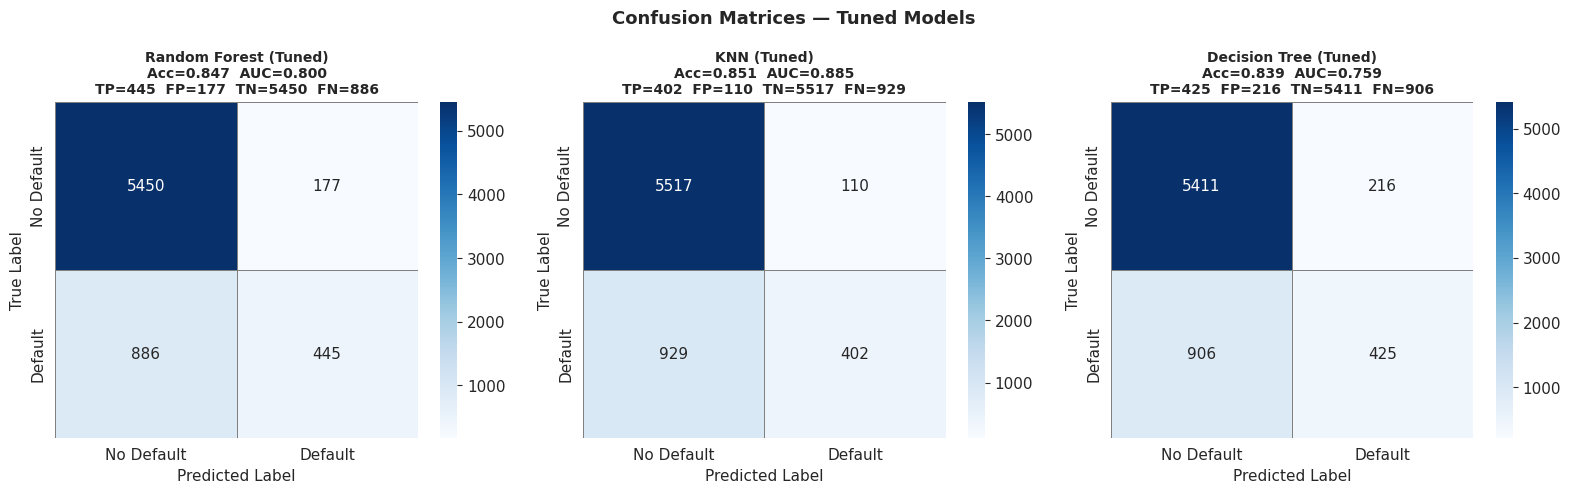

In [71]:
# task 4: visual diagnostics , confusion matrices.
# confusion matrices (tuned models only)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, res) in enumerate(results_tuned.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=['No Default', 'Default'],
        yticklabels=['No Default', 'Default'],
        linewidths=0.5, linecolor='gray'
    )
    axes[idx].set_title(
        f'{name}\n'
        f'Acc={res["Accuracy"]:.3f}  AUC={res["AUC-ROC"]:.3f}\n'
        f'TP={tp}  FP={fp}  TN={tn}  FN={fn}',
        fontweight='bold', fontsize=10
    )
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Tuned Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_confusion_matrices_tuned.png', dpi=72, bbox_inches='tight')
plt.show()


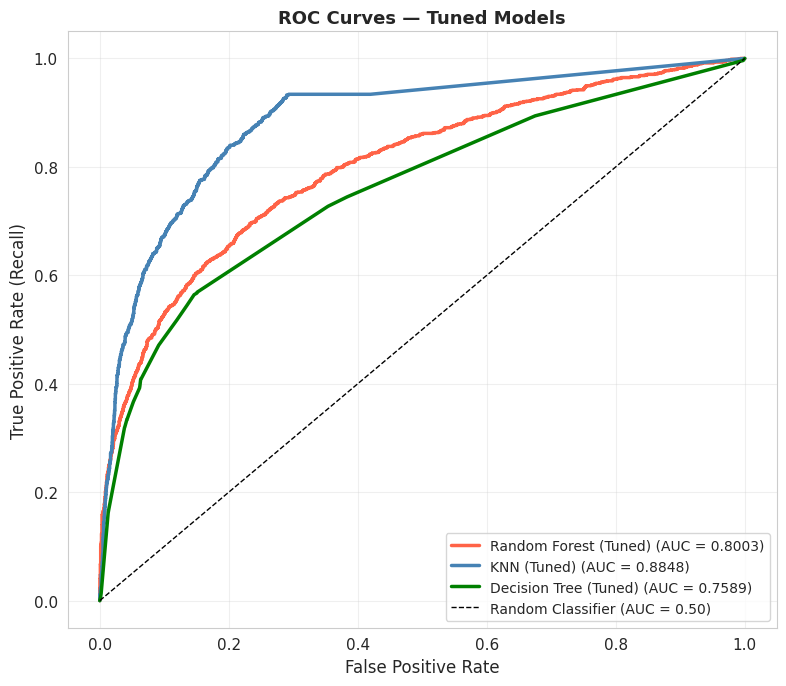

In [73]:
# ROC curves (tuned models only)
# Task 4: ROC curves — AUC-ROC

plt.figure(figsize=(8, 7))
colors_roc = ['tomato', 'steelblue', 'green']

for i, (name, res) in enumerate(results_tuned.items()):
    # roc_curve uses stored y_prob — no new prediction needed
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=colors_roc[i], linewidth=2.5,
             label=f'{name} (AUC = {res["AUC-ROC"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — Tuned Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('08_roc_curves_tuned.png', dpi=72, bbox_inches='tight')
plt.show()

Initialising SHAP TreeExplainer
Computing SHAP values on 200 test samples

shap_values type: <class 'numpy.ndarray'>
Format: 3D ARRAY — shap_values[:,:,1].shape = (200, 27) 
 Shapes match.


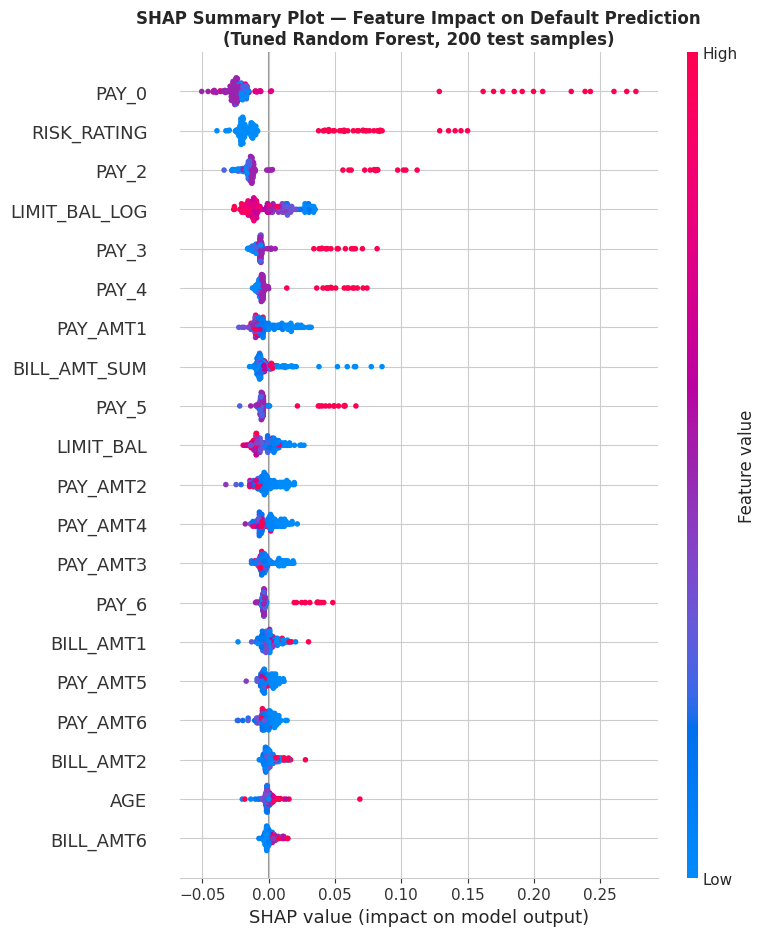

In [96]:
# SHAP ANALYSIS (Tuned Random Forest)
# Task 4: Use SHAP to interpret the best model's predictions.

# WHY Random Forest for SHAP (even if KNN won on AUC): shap.TreeExplainer is designed specifically for tree-based models and computes EXACT Shapley values via tree paths.
# For KNN there is no equivalent , KernelExplainer would be used instead but is ~100× slower and approximate.
# The Random Forest is the best INTERPRETABLE model and gives the most reliable feature attribution.

print("Initialising SHAP TreeExplainer")
explainer = shap.TreeExplainer(best_rf)

# 200 random test samples , sufficient for reliable SHAP estimates on a 27-feature dataset.
np.random.seed(42)
sample_idx    = np.random.choice(len(X_test_scaled), size=200, replace=False)
X_shap_sample = X_test_scaled.iloc[sample_idx].reset_index(drop=True)

print("Computing SHAP values on 200 test samples")
shap_values = explainer.shap_values(X_shap_sample)
print(f"\nshap_values type: {type(shap_values)}")

if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
    print(f"Format: LIST — shap_values[1].shape = {shap_values[1].shape} ✅")
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals_class1 = shap_values[:, :, 1]
    print(f"Format: 3D ARRAY — shap_values[:,:,1].shape = {shap_vals_class1.shape} ")
else:
    shap_vals_class1 = shap_values
    print(f"Format: 2D ARRAY — shape = {shap_vals_class1.shape} ")

# Shape assertion
assert shap_vals_class1.shape == X_shap_sample.shape, \
    f"Shape mismatch: SHAP {shap_vals_class1.shape} vs X {X_shap_sample.shape}"
print(" Shapes match.")

plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_vals_class1,
    X_shap_sample,
    feature_names=X.columns.tolist(),
    show=False,
    max_display=20
)
plt.title('SHAP Summary Plot — Feature Impact on Default Prediction\n'
          '(Tuned Random Forest, 200 test samples)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('09_shap_summary_beeswarm.png', dpi=72, bbox_inches='tight')
plt.show()


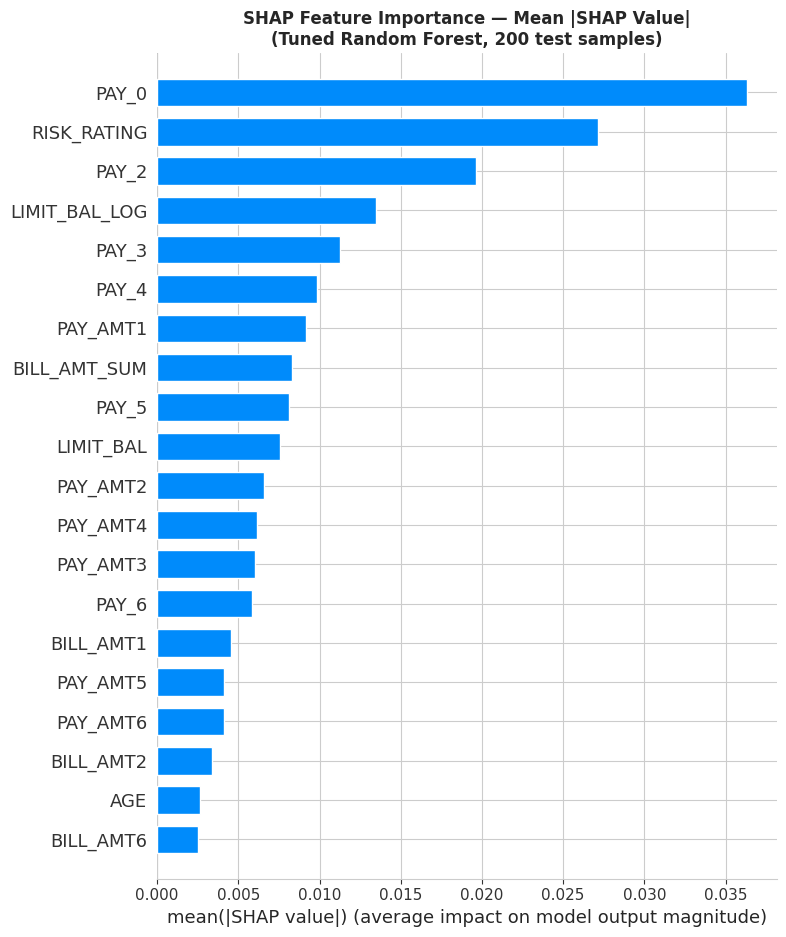

In [81]:
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_vals_class1,
    X_shap_sample,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|\n'
          '(Tuned Random Forest, 200 test samples)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('10_shap_feature_importance_bar.png', dpi=72, bbox_inches='tight')
plt.show()

In [94]:
# SHAP Rankings Table
mean_abs_shap = pd.DataFrame({
    'Feature'          : X.columns.tolist(),
    'Mean |SHAP Value|': np.abs(shap_vals_class1).mean(axis=0)
}).sort_values('Mean |SHAP Value|', ascending=False).reset_index(drop=True)

print("SHAP Feature Importance Rankings")
print(mean_abs_shap.to_string())
print("---------------------------------------------")

for feat in ['RISK_RATING', 'PAY_0', 'LIMIT_BAL', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG']:
    if feat in mean_abs_shap['Feature'].values:
        row  = mean_abs_shap[mean_abs_shap['Feature'] == feat].iloc[0]
        rank = mean_abs_shap[mean_abs_shap['Feature'] == feat].index[0] + 1
        print(f"{feat:20s}: Mean|SHAP|={row['Mean |SHAP Value|']:.5f} (Rank #{rank})")
print("risk_leak: DROPPED before training , not in SHAP")

SHAP Feature Importance Rankings
          Feature  Mean |SHAP Value|
0           PAY_0           0.036348
1     RISK_RATING           0.027173
2           PAY_2           0.019644
3   LIMIT_BAL_LOG           0.013455
4           PAY_3           0.011288
5           PAY_4           0.009829
6        PAY_AMT1           0.009152
7    BILL_AMT_SUM           0.008327
8           PAY_5           0.008126
9       LIMIT_BAL           0.007592
10       PAY_AMT2           0.006606
11       PAY_AMT4           0.006145
12       PAY_AMT3           0.006011
13          PAY_6           0.005825
14      BILL_AMT1           0.004562
15       PAY_AMT5           0.004146
16       PAY_AMT6           0.004105
17      BILL_AMT2           0.003387
18            AGE           0.002631
19      BILL_AMT6           0.002532
20      BILL_AMT3           0.002367
21      BILL_AMT5           0.002205
22      BILL_AMT4           0.001907
23   CITY_encoded           0.001429
24       MARRIAGE           0.001123
25   

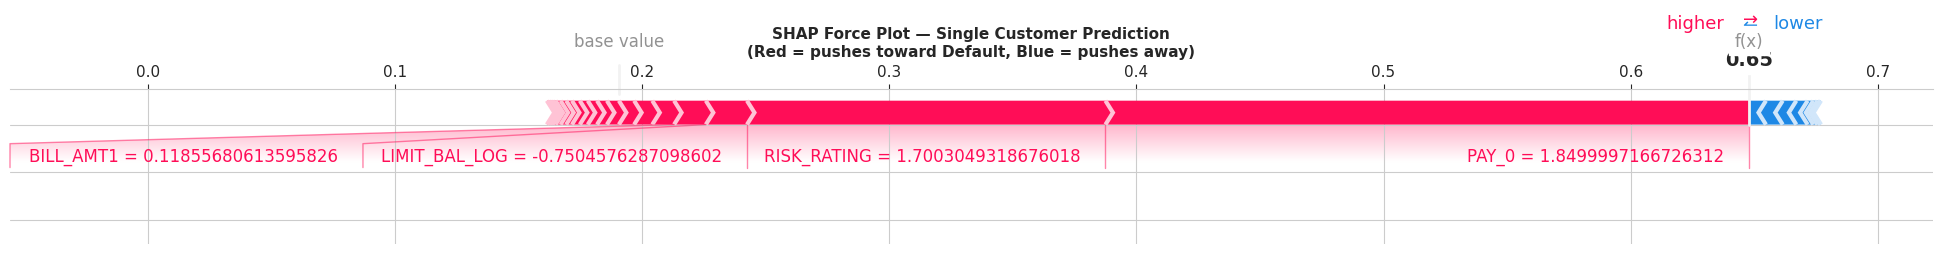

 Figures saved: 5 (confusion matrices, ROC, SHAP ×3)
 Best model by AUC: KNN (Tuned)
 Best AUC-ROC: 0.8848


In [95]:
#SHAP and LIME tell you which features were most influential for THIS ONE prediction

shap.initjs()
shap.force_plot(
    base_value    = explainer.expected_value[1]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value,
    shap_values   = shap_vals_class1[0],
    features      = X_shap_sample.iloc[0],
    feature_names = X.columns.tolist(),
    matplotlib    = True,
    show          = False
)
plt.title('SHAP Force Plot — Single Customer Prediction\n'
          '(Red = pushes toward Default, Blue = pushes away)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('11_shap_force_plot_single.png', dpi=72, bbox_inches='tight')
plt.show()

print(f" Figures saved: 5 (confusion matrices, ROC, SHAP ×3)")
print(f" Best model by AUC: {final_comparison.iloc[0]['Model']}")
print(f" Best AUC-ROC: {final_comparison.iloc[0]['AUC-ROC']}")